# Notebook 06: Evaluation

**CRISP-DM Phase: Evaluation**

Comprehensive evaluation comparing RAG vs Baseline using:
1. **ROUGE-L** — Text overlap with ground truth
2. **Semantic Similarity** — Embedding-based answer similarity
3. **Faithfulness** — Is the answer grounded in context?
4. **Context Precision** — Are retrieved chunks relevant?
5. **Context Recall** — Does retrieval cover the needed information?

In [1]:
# Standard imports
import sys
import json
from pathlib import Path

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Project imports
from src.config import GROUND_TRUTH_DIR, METRICS_DIR, FIGURES_DIR
from src.embeddings import EmbeddingModel
from src.evaluator import (
    evaluate_batch, evaluate_single,
    load_ground_truth, save_evaluation_results,
    print_evaluation_summary,
    compute_rouge_l, compute_faithfulness_simple,
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# Load ground truth and batch results
ground_truths = load_ground_truth(GROUND_TRUTH_DIR / 'qa_pairs.json')

with open(METRICS_DIR / 'rag_batch_results.json', 'r') as f:
    batch_data = json.load(f)
    batch_results = batch_data['results']

print(f"Ground truth pairs: {len(ground_truths)}")
print(f"Batch results: {len(batch_results)}")

2026-04-09 12:34:55,532 - rag_qa_system - INFO - Loaded 51 ground truth Q&A pairs


Ground truth pairs: 51
Batch results: 51


In [3]:
# Initialize embedding model for semantic similarity
embedding_model = EmbeddingModel('bge')

2026-04-09 12:34:58,800 - sentence_transformers.SentenceTransformer - INFO - Use pytorch device_name: cuda:0


2026-04-09 12:34:58,801 - sentence_transformers.SentenceTransformer - INFO - Load pretrained SentenceTransformer: BAAI/bge-small-en-v1.5


2026-04-09 12:34:59,145 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"


2026-04-09 12:34:59,170 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-small-en-v1.5/5c38ec7c405ec4b44b94cc5a9bb96e735b38267a/modules.json "HTTP/1.1 200 OK"


2026-04-09 12:34:59,553 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"


...

2026-04-09 12:35:03,004 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-small-en-v1.5/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"


2026-04-09 12:35:03,340 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-small-en-v1.5/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"


2026-04-09 12:35:03,362 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-small-en-v1.5/5c38ec7c405ec4b44b94cc5a9bb96e735b38267a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


2026-04-09 12:35:03,750 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-small-en-v1.5 "HTTP/1.1 200 OK"


2026-04-09 12:35:03,902 - rag_qa_system - INFO - Loaded embedding model 'bge' (dims=384, backend=sentence_transformers, load_time=8.37s)


## 6.1 Run Full Evaluation

In [4]:
# Evaluate all results
evaluation = evaluate_batch(
    results=batch_results,
    ground_truths=ground_truths,
    embedding_model=embedding_model,
)

# Print summary
print_evaluation_summary(evaluation['aggregate'])
print(f"\nTotal questions evaluated: {evaluation['num_evaluated']}")


EVALUATION SUMMARY: RAG vs Baseline

Metric                           RAG   Baseline  Improvement
------------------------------------------------------------
  rouge_l_f1                  0.2036     0.2020        +0.8%
  rouge_l_precision           0.1661     0.1492       +11.3%
  rouge_l_recall              0.3195     0.3909       -18.3%
  answer_similarity           0.8495     0.8689        -2.2%
  faithfulness                0.0000        N/A          N/A
  context_precision           0.0000        N/A          N/A
  context_recall              0.0000        N/A          N/A

Total questions evaluated: 51


## 6.2 Per-Question Analysis

In [5]:
# Create per-question DataFrame
per_q_data = []
for eval_item in evaluation['per_question']:
    per_q_data.append({
        'Question': eval_item['question'][:50] + '...',
        'RAG ROUGE-L': eval_item['rag']['rouge_l_f1'],
        'Baseline ROUGE-L': eval_item['baseline']['rouge_l_f1'],
        'RAG Similarity': eval_item['rag']['answer_similarity'],
        'Baseline Similarity': eval_item['baseline']['answer_similarity'],
        'Faithfulness': eval_item['rag']['faithfulness'],
        'Context Precision': eval_item['rag']['context_precision'],
        'Context Recall': eval_item['rag']['context_recall'],
    })

eval_df = pd.DataFrame(per_q_data)
print(eval_df.to_string(index=False))

                                             Question  RAG ROUGE-L  Baseline ROUGE-L  RAG Similarity  Baseline Similarity  Faithfulness  Context Precision  Context Recall
What is Ireland's 2030 greenhouse gas emissions re...       0.2162            0.4000          0.8689               0.8907           0.0                0.0             0.0
     When must Ireland achieve climate neutrality?...       0.1408            0.3143          0.8532               0.9001           0.0                0.0             0.0
What are Ireland's three carbon budgets and their ...       0.1944            0.0635          0.9433               0.8971           0.0                0.0             0.0
What percentage of electricity does Ireland aim to...       0.5405            0.4643          0.8865               0.8664           0.0                0.0             0.0
What is Ireland's offshore wind energy target for ...       0.1250            0.2000          0.8268               0.7969           0.0          

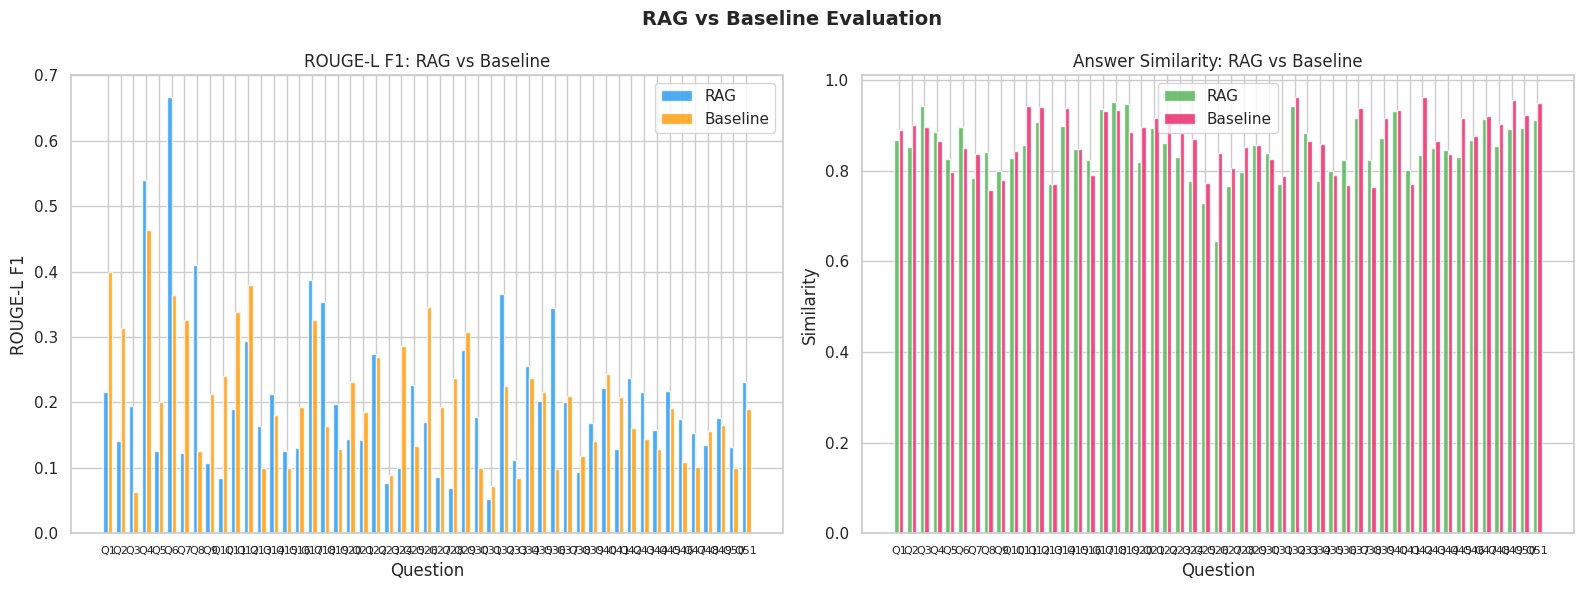

In [6]:
# RAG vs Baseline ROUGE-L comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROUGE-L comparison
x = range(len(eval_df))
width = 0.35
axes[0].bar([i - width/2 for i in x], eval_df['RAG ROUGE-L'], width, 
            label='RAG', color='#2196F3', alpha=0.8)
axes[0].bar([i + width/2 for i in x], eval_df['Baseline ROUGE-L'], width, 
            label='Baseline', color='#FF9800', alpha=0.8)
axes[0].set_xlabel('Question')
axes[0].set_ylabel('ROUGE-L F1')
axes[0].set_title('ROUGE-L F1: RAG vs Baseline')
axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)

# Semantic Similarity comparison
axes[1].bar([i - width/2 for i in x], eval_df['RAG Similarity'], width, 
            label='RAG', color='#4CAF50', alpha=0.8)
axes[1].bar([i + width/2 for i in x], eval_df['Baseline Similarity'], width, 
            label='Baseline', color='#E91E63', alpha=0.8)
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Similarity')
axes[1].set_title('Answer Similarity: RAG vs Baseline')
axes[1].legend()
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)

plt.suptitle('RAG vs Baseline Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'rag_vs_baseline_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6.3 RAG-Specific Metrics

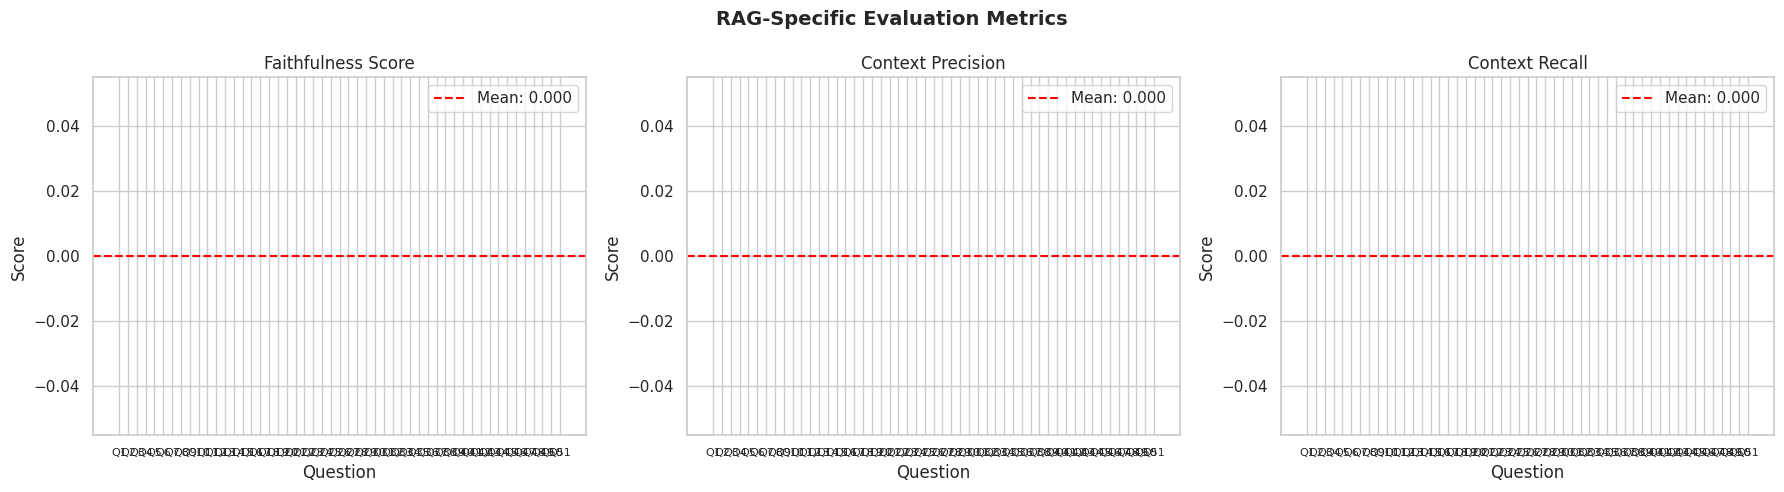

In [7]:
# RAG-specific metrics visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Faithfulness
axes[0].bar(x, eval_df['Faithfulness'], color='#2196F3', alpha=0.8)
axes[0].axhline(eval_df['Faithfulness'].mean(), color='red', linestyle='--', 
                label=f'Mean: {eval_df["Faithfulness"].mean():.3f}')
axes[0].set_title('Faithfulness Score')
axes[0].set_xlabel('Question')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)

# Context Precision
axes[1].bar(x, eval_df['Context Precision'], color='#4CAF50', alpha=0.8)
axes[1].axhline(eval_df['Context Precision'].mean(), color='red', linestyle='--',
                label=f'Mean: {eval_df["Context Precision"].mean():.3f}')
axes[1].set_title('Context Precision')
axes[1].set_xlabel('Question')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)

# Context Recall
axes[2].bar(x, eval_df['Context Recall'], color='#FF9800', alpha=0.8)
axes[2].axhline(eval_df['Context Recall'].mean(), color='red', linestyle='--',
                label=f'Mean: {eval_df["Context Recall"].mean():.3f}')
axes[2].set_title('Context Recall')
axes[2].set_xlabel('Question')
axes[2].set_ylabel('Score')
axes[2].legend()
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)

plt.suptitle('RAG-Specific Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(FIGURES_DIR / 'rag_specific_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6.4 Aggregate Summary

In [8]:
# Create aggregate summary table
agg = evaluation['aggregate']

summary_data = []
for metric in agg.get('rag', {}):
    row = {
        'Metric': metric,
        'RAG': f"{agg['rag'][metric]:.4f}",
        'Baseline': f"{agg['baseline'].get(metric, 'N/A')}",
    }
    if metric in agg.get('improvements_pct', {}):
        imp = agg['improvements_pct'][metric]
        row['Improvement'] = f"{imp:+.1f}%"
        row['Winner'] = '✅ RAG' if imp > 0 else '❌ Baseline'
    else:
        row['Improvement'] = 'N/A'
        row['Winner'] = 'RAG only'
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\nAGGREGATE EVALUATION SUMMARY")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)


AGGREGATE EVALUATION SUMMARY
           Metric    RAG Baseline Improvement     Winner
       rouge_l_f1 0.2036    0.202       +0.8%      ✅ RAG
rouge_l_precision 0.1661   0.1492      +11.3%      ✅ RAG
   rouge_l_recall 0.3195   0.3909      -18.3% ❌ Baseline
answer_similarity 0.8495   0.8689       -2.2% ❌ Baseline
     faithfulness 0.0000      N/A         N/A   RAG only
context_precision 0.0000      N/A         N/A   RAG only
   context_recall 0.0000      N/A         N/A   RAG only


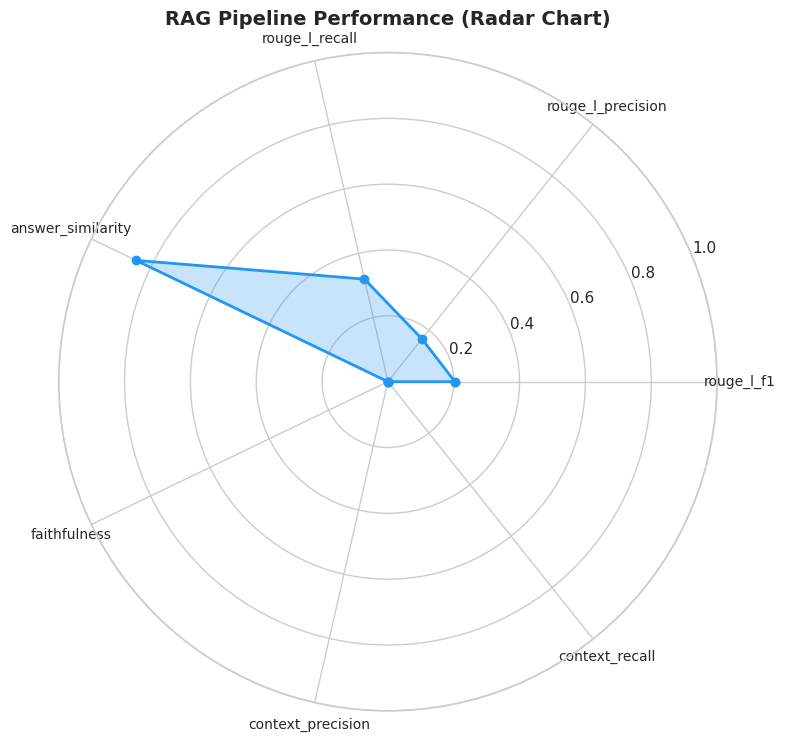

In [9]:
# Radar chart for RAG metrics
rag_metrics = agg.get('rag', {})
metric_names = list(rag_metrics.keys())
metric_values = list(rag_metrics.values())

if metric_names:
    # Close the polygon
    angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
    metric_values_closed = metric_values + [metric_values[0]]
    angles_closed = angles + [angles[0]]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    ax.fill(angles_closed, metric_values_closed, alpha=0.25, color='#2196F3')
    ax.plot(angles_closed, metric_values_closed, 'o-', linewidth=2, color='#2196F3')
    ax.set_xticks(angles)
    ax.set_xticklabels(metric_names, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('RAG Pipeline Performance (Radar Chart)', pad=20, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / 'rag_radar_chart.png'), dpi=150, bbox_inches='tight')
    plt.show()

In [10]:
# Save evaluation results
save_evaluation_results(evaluation, 'main_evaluation')
print("✅ Evaluation results saved")

2026-04-09 12:35:08,335 - rag_qa_system - INFO - Evaluation results saved to /home/umukesh/Desktop/dl/results/metrics/eval_main_evaluation.json


✅ Evaluation results saved


## 6.5 Summary

✅ Full evaluation of RAG vs Baseline across all metrics  
✅ Per-question detailed analysis  
✅ Visualization of all metrics  
✅ Aggregate summary with improvement percentages  

**Next**: Notebook 07 — Results Visualization (publication-quality figures)